Cargando dataset limpio...


C:\Users\HP LAUTARO\AppData\Local\Temp\ipykernel_20264\2679602718.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='sentiment', palette='Set2')


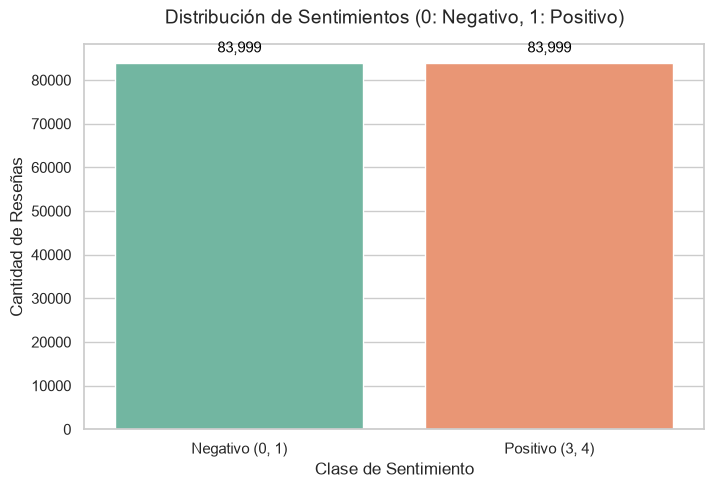

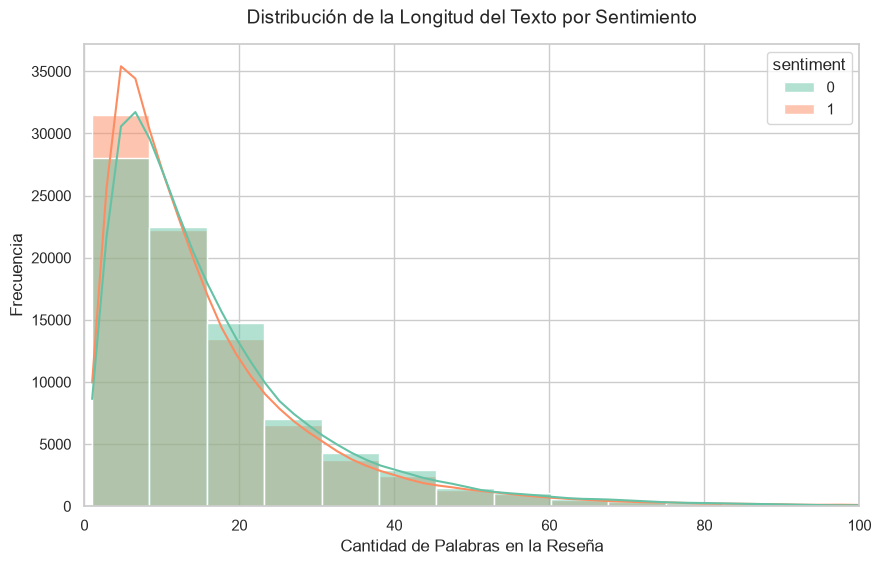

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset LIMPIO que generamos recién
print("Cargando dataset limpio...")
df = pd.read_csv('../data/processed/amazon_reviews_clean.csv')

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# GRÁFICO 1: Balance de clases (Sentimiento)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Distribución de Sentimientos (0: Negativo, 1: Positivo)', fontsize=14, pad=15)
plt.xlabel('Clase de Sentimiento', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Negativo (0, 1)', 'Positivo (3, 4)'])

# Agregar los números exactos arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()


# ---------------------------------------------------------
# GRÁFICO 2: Distribución de la longitud de las reseñas
# ---------------------------------------------------------
# Calcular cantidad de palabras por cada reseña procesada
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True, palette='Set2')
plt.title('Distribución de la Longitud del Texto por Sentimiento', fontsize=14, pad=15)
plt.xlabel('Cantidad de Palabras en la Reseña', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# Limitamos el eje X a 100 palabras para evitar que valores atípicos extremos deformen el gráfico
plt.xlim(0, 100) 
plt.show()